# Train Faster R-CNN ResNet-50-FPN trên Kaggle

Notebook one-click: bật **GPU** và **Internet**, Add Input processed VisDrone và raw `VisDrone2019-DET-val`, rồi chọn **Run All**. Từ F5, mỗi epoch được đánh giá bằng VisDrone DET metric và `best.pth` được chọn theo `visdrone_ap`.

- `F0`: baseline pretrained COCO, không augmentation.
- `F1`: giữ nguyên cấu hình F0, chỉ thêm augmentation bbox-safe.
- `F2`: giữ nguyên F0, chỉ thay anchor FPN thành `8,16,32,64,128` cho vật thể nhỏ.
- `F3`: giữ nguyên F0, chỉ tăng RPN proposals cho ảnh crowded.
- `F4`: giữ proposals của F3, đổi sang Faster R-CNN ResNet-50-FPN V2 pretrained COCO.
- `F5`: giữ F4, tăng input resize từ `800/1333` lên `896/1493` (an toàn cho T4 16 GB).
- Smoke test chạy 2 batch để kiểm tra pipeline; kết quả không dùng để báo cáo.


## 1. Cấu hình

F5 cần processed dataset để train và raw validation để giữ ignore regions khi đánh giá. Khi resume, chỉ dùng `last.pth` của chính F5.


In [1]:
from pathlib import Path

EXPERIMENT = "F5"           # F5 = F4 + input resolution 896/1493
RUN_SMOKE_FIRST = False       # smoke F5 đã qua; tránh tốn thời gian khi chạy lại
TRAIN_FULL = True             # train đủ EPOCHS ngay sau smoke test
EPOCHS = 25
BATCH_SIZE = 1 if EXPERIMENT in {"F4", "F5"} else 2
MIN_SIZE = 896 if EXPERIMENT == "F5" else 800
MAX_SIZE = 1493 if EXPERIMENT == "F5" else 1333
WORKERS = 2
SEED = 42

REPO_URL = "https://github.com/Nhattk19/Object_dectection.git"
REPO_BRANCH = "cnn-faster-rcnn-pipeline"
PROJECT_ROOT_OVERRIDE = None  # thường không cần sửa
PROCESSED_DATA_ROOT = None    # tự tìm trong /kaggle/input; có thể điền thủ công
RAW_VAL_ROOT = None           # raw VisDrone2019-DET-val có images/ + annotations/
RESUME_FROM = None            # ví dụ: /kaggle/input/f0-checkpoint/f0/last.pth
OUTPUT_ROOT = Path("/kaggle/working/faster_rcnn_runs")

assert EXPERIMENT in {"F0", "F1", "F2", "F3", "F4", "F5"}


## 2. Clone repository và kiểm tra GPU


In [2]:
import importlib.util
import subprocess
import sys

def find_project_root():
    if PROJECT_ROOT_OVERRIDE:
        candidate = Path(PROJECT_ROOT_OVERRIDE)
        if (candidate / "src" / "faster_rcnn.py").is_file():
            return candidate.resolve()
        raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE không hợp lệ: {candidate}")
    direct = [Path.cwd(), *Path.cwd().parents, Path("/kaggle/working")]
    for candidate in direct:
        if (candidate / "src" / "faster_rcnn.py").is_file():
            return candidate.resolve()
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = list(base.glob("**/src/faster_rcnn.py"))
            if matches:
                return matches[0].parents[1].resolve()
    clone_dir = Path("/kaggle/working/Object_dectection")
    subprocess.check_call(["git", "clone", "--depth", "1", "--branch",
                           REPO_BRANCH, REPO_URL, str(clone_dir)])
    return clone_dir.resolve()

PROJECT_ROOT = find_project_root()
if importlib.util.find_spec("pycocotools") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pycocotools>=2.0.7"])

import torch, torchvision
assert torch.cuda.is_available(), "Chưa có CUDA. Vào Kaggle Settings và bật GPU Accelerator."
print({"project": str(PROJECT_ROOT), "torch": torch.__version__,
       "torchvision": torchvision.__version__, "gpu": torch.cuda.get_device_name(0)})


Cloning into '/kaggle/working/Object_dectection'...


{'project': '/kaggle/working/Object_dectection', 'torch': '2.10.0+cu128', 'torchvision': '0.25.0+cu128', 'gpu': 'Tesla T4'}


## 3. Tìm và kiểm tra processed COCO dataset

Dataset đã Add Input phải chứa `images/train`, `images/val`, `annotations/instances_train.json` và `instances_val.json`. Upload processed data giúp không phải chuyển đổi lại trong mỗi Kaggle session.


In [3]:
def valid_processed_root(path):
    path = Path(path)
    return all((path / item).exists() for item in (
        "images", "annotations/instances_train.json", "annotations/instances_val.json"
    ))

if PROCESSED_DATA_ROOT:
    DATA_ROOT = Path(PROCESSED_DATA_ROOT)
    if not valid_processed_root(DATA_ROOT):
        raise FileNotFoundError(f"Processed dataset không hợp lệ: {DATA_ROOT}")
else:
    candidates = []
    for base in (Path("/kaggle/input"), PROJECT_ROOT / "data"):
        if base.exists():
            candidates.extend(p.parent.parent for p in base.glob("**/annotations/instances_train.json"))
    DATA_ROOT = next((p for p in candidates if valid_processed_root(p)), None)

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Không tìm thấy processed VisDrone trong Kaggle Input. Hãy upload/add thư mục "
        "data/processed/VisDrone hoặc đặt PROCESSED_DATA_ROOT thủ công."
    )

assert valid_processed_root(DATA_ROOT)
import json
train_payload = json.loads((DATA_ROOT / "annotations/instances_train.json").read_text())
val_payload = json.loads((DATA_ROOT / "annotations/instances_val.json").read_text())
def valid_raw_val(path):
    path = Path(path)
    return (path / "images").is_dir() and len(list((path / "annotations").glob("*.txt"))) >= 500

if RAW_VAL_ROOT:
    RAW_ROOT = Path(RAW_VAL_ROOT)
else:
    RAW_ROOT = next((p.parent for p in Path("/kaggle/input").glob("**/annotations")
                     if valid_raw_val(p.parent)), None)
if EXPERIMENT == "F5" and (RAW_ROOT is None or not valid_raw_val(RAW_ROOT)):
    raise FileNotFoundError("F5 cần Add Input raw VisDrone2019-DET-val để evaluate toolkit")

print({"processed_root": str(DATA_ROOT), "raw_val_root": str(RAW_ROOT),
       "train_images": len(train_payload["images"]),
       "train_boxes": len(train_payload["annotations"]),
       "val_images": len(val_payload["images"]),
       "val_boxes": len(val_payload["annotations"])})


{'processed_root': '/kaggle/input/datasets/aimy144/visdrone/VisDrone', 'raw_val_root': '/kaggle/input/datasets/huynglhong/visdrone2019-det-val', 'train_images': 6471, 'train_boxes': 343204, 'val_images': 548, 'val_boxes': 38759}


## 4. Preview ground truth và augmentation

Ảnh bên trái là dữ liệu gốc; bên phải là augmentation bbox-safe của F1. F0 không dùng augmentation khi train.


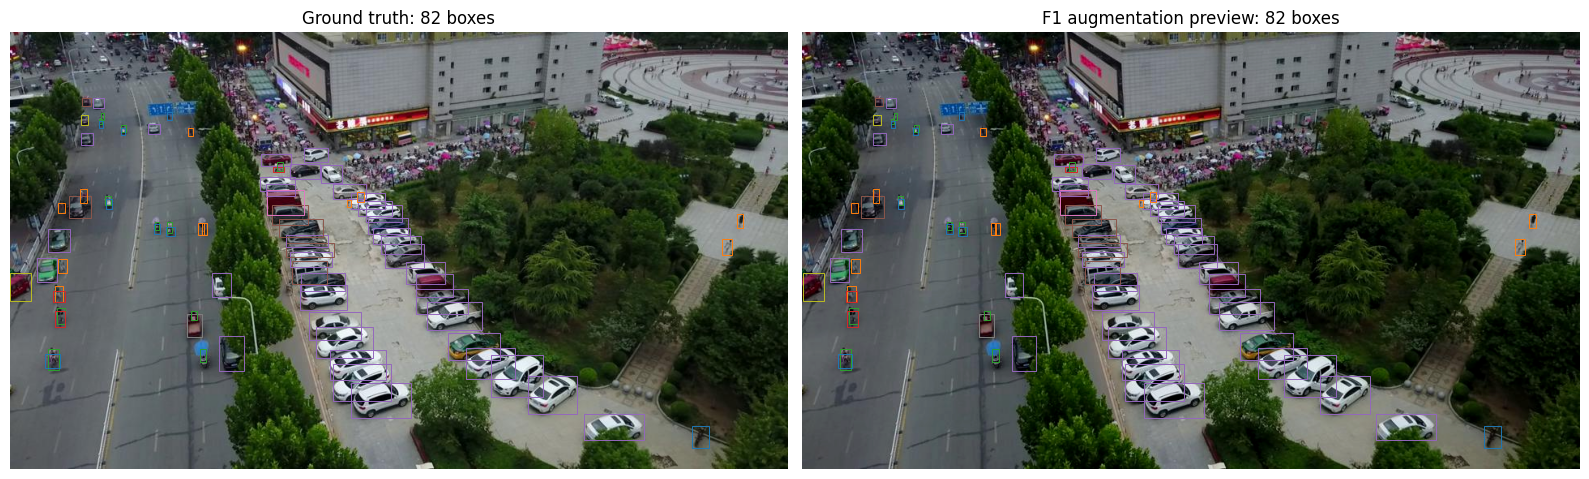

In [4]:
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from augmentation import ControlledDetectionAugmenter
from faster_rcnn import VISDRONE_CLASS_NAMES, VisDroneCocoDataset

TRAIN_JSON = DATA_ROOT / "annotations/instances_train.json"
IMAGE_ROOT = DATA_ROOT / "images"
plain_dataset = VisDroneCocoDataset(TRAIN_JSON, IMAGE_ROOT)
aug_dataset = VisDroneCocoDataset(
    TRAIN_JSON, IMAGE_ROOT, augmentation=ControlledDetectionAugmenter(seed=SEED)
)

def draw_sample(ax, image, target, title, max_boxes=150):
    ax.imshow(image.permute(1, 2, 0).numpy())
    for box, label in zip(target["boxes"][:max_boxes], target["labels"][:max_boxes]):
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                               edgecolor=plt.cm.tab10(int(label) % 10), linewidth=.7))
    ax.set_title(f"{title}: {len(target['boxes'])} boxes")
    ax.axis("off")

plain_image, plain_target = plain_dataset[0]
aug_image, aug_target = aug_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
draw_sample(axes[0], plain_image, plain_target, "Ground truth")
draw_sample(axes[1], aug_image, aug_target, "F1 augmentation preview")
plt.tight_layout(); plt.show()


## 5. Smoke test rồi train full

Notebook tự chạy smoke test trong thư mục riêng, sau đó khởi tạo lại model pretrained COCO để train full. Output gồm `last.pth`, `best.pth`, `history.csv`, `learning_curves.png`, `config.json` và `summary.json`.


In [5]:
import os

def run_training(output_root, *, smoke=False, resume_from=None):
    command = [
        sys.executable, "-u", str(PROJECT_ROOT / "scripts/train_faster_rcnn.py"),
        "--data-root", str(DATA_ROOT), "--output-dir", str(output_root),
        "--experiment", EXPERIMENT, "--epochs", str(EPOCHS),
        "--batch-size", str(BATCH_SIZE), "--workers", str(WORKERS),
        "--seed", str(SEED), "--min-size", str(MIN_SIZE),
        "--max-size", str(MAX_SIZE),
    ]
    if RAW_ROOT:
        command.extend(["--raw-val-root", str(RAW_ROOT)])
    if smoke:
        command.append("--smoke-test")
    if resume_from:
        command.extend(["--resume", str(resume_from)])
    print("Running:", " ".join(command))
    process_env = os.environ.copy()
    process_env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    process_env["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
    subprocess.check_call(command, cwd=PROJECT_ROOT, env=process_env)

if RUN_SMOKE_FIRST and not RESUME_FROM:
    run_training(Path("/kaggle/working/smoke_runs"), smoke=True)
if TRAIN_FULL:
    run_training(OUTPUT_ROOT, resume_from=RESUME_FROM)


Running: /usr/bin/python3 -u /kaggle/working/Object_dectection/scripts/train_faster_rcnn.py --data-root /kaggle/input/datasets/aimy144/visdrone/VisDrone --output-dir /kaggle/working/faster_rcnn_runs --experiment F5 --epochs 25 --batch-size 1 --workers 2 --seed 42 --min-size 896 --max-size 1493 --raw-val-root /kaggle/input/datasets/huynglhong/visdrone2019-det-val
{
  "config": {
    "experiment": "F5",
    "data_root": "/kaggle/input/datasets/aimy144/visdrone/VisDrone",
    "output_dir": "/kaggle/working/faster_rcnn_runs/f5",
    "epochs": 25,
    "batch_size": 1,
    "accumulation_steps": 2,
    "effective_batch_size": 2,
    "workers": 2,
    "seed": 42,
    "min_size": 896,
    "max_size": 1493,
    "pretrained": true,
    "initialize_from_pretrained_this_run": true,
    "augmentation": false,
    "small_anchors": false,
    "crowded_proposals": true,
    "model_version": "v2",
    "evaluator": "visdrone_det",
    "selection_metric": "visdrone_ap",
    "raw_val_root": "/kaggle/input/

100%|██████████| 167M/167M [00:01<00:00, 148MB/s]


Epoch 1/25


{"epoch": 1, "lr": 0.0025, "loss_classifier": 0.42775231657722157, "loss_box_reg": 0.3893841565351313, "loss_objectness": 0.11263529510843047, "loss_rpn_box_reg": 0.18676375983845986, "loss_total": 1.116535527407985, "seconds": 1386.013767503, "visdrone_ap": 0.2308678674512991, "visdrone_ap50": 0.43769595375471176, "visdrone_ap75": 0.215639042800083, "visdrone_ar1": 0.004516512923847013, "visdrone_ar10": 0.04750064324609414, "visdrone_ar100": 0.3022302047158788, "visdrone_ar500": 0.4259125050886817, "images": 548}
Epoch 2/25


{"epoch": 2, "lr": 0.0025, "loss_classifier": 0.342996247998738, "loss_box_reg": 0.3501802183884285, "loss_objectness": 0.07443252606723262, "loss_rpn_box_reg": 0.16149367769150016, "loss_total": 0.9291026705527412, "seconds": 1340.015428781, "visdrone_ap": 0.24465874592364484, "visdrone_ap50": 0.44820113825527086, "visdrone_ap75": 0.23267859923704118, "visdrone_ar1": 0.00627454684523894, "visdrone_ar10": 0.056627584526634245, "visdrone_ar100": 0.32182433131499993, "visdrone_ar500": 0.42913338460573874, "images": 548}
Epoch 3/25


...

{"epoch": 21, "lr": 2.5e-05, "loss_classifier": 0.11808513007926238, "loss_box_reg": 0.199096554626537, "loss_objectness": 0.017049684301238467, "loss_rpn_box_reg": 0.07781139979680375, "loss_total": 0.41204276868491774, "seconds": 1348.8384503029993, "visdrone_ap": 0.2600507710061662, "visdrone_ap50": 0.4701079802800199, "visdrone_ap75": 0.24953798778776393, "visdrone_ar1": 0.009465220781787962, "visdrone_ar10": 0.06861006414077694, "visdrone_ar100": 0.3431002510093136, "visdrone_ar500": 0.41848719465682904, "images": 548}
Epoch 22/25


{"epoch": 22, "lr": 2.5e-05, "loss_classifier": 0.1167673057515066, "loss_box_reg": 0.197091767168701, "loss_objectness": 0.017057117834003592, "loss_rpn_box_reg": 0.07727428855033396, "loss_total": 0.4081904795468418, "seconds": 1349.5853172869975, "visdrone_ap": 0.2693937407057642, "visdrone_ap50": 0.4857383525385751, "visdrone_ap75": 0.25840255302215515, "visdrone_ar1": 0.010015321856640506, "visdrone_ar10": 0.06899468305377218, "visdrone_ar100": 0.3514633060334699, "visdrone_ar500": 0.428180326659455, "images": 548}
Epoch 23/25


{"epoch": 23, "lr": 2.5e-05, "loss_classifier": 0.11615756934901159, "loss_box_reg": 0.19603297046667506, "loss_objectness": 0.016717119056805105, "loss_rpn_box_reg": 0.07678001582372083, "loss_total": 0.40568767447308685, "seconds": 1349.4549857210004, "visdrone_ap": 0.2605514069125393, "visdrone_ap50": 0.47490635408927534, "visdrone_ap75": 0.24685817501242183, "visdrone_ar1": 0.009011370398171408, "visdrone_ar10": 0.0679842837362959, "visdrone_ar100": 0.3395978889093044, "visdrone_ar500": 0.41761771028153544, "images": 548}
Epoch 24/25


{"epoch": 24, "lr": 2.5e-05, "loss_classifier": 0.11498039046373967, "loss_box_reg": 0.1949927878176128, "loss_objectness": 0.016846373136386178, "loss_rpn_box_reg": 0.07669872764207229, "loss_total": 0.4035182791121455, "seconds": 1349.4333326880005, "visdrone_ap": 0.2726684412362086, "visdrone_ap50": 0.4896654895389587, "visdrone_ap75": 0.2639356817570105, "visdrone_ar1": 0.011685912167012646, "visdrone_ar10": 0.07117529064644695, "visdrone_ar100": 0.353618493087528, "visdrone_ar500": 0.4333546341979396, "images": 548}
Epoch 25/25


{"epoch": 25, "lr": 2.5e-05, "loss_classifier": 0.11399274758413565, "loss_box_reg": 0.19417968794441257, "loss_objectness": 0.016556351883762643, "loss_rpn_box_reg": 0.07619571185587257, "loss_total": 0.4009244993232332, "seconds": 1348.4859584169972, "visdrone_ap": 0.26153251917590387, "visdrone_ap50": 0.4746451283443261, "visdrone_ap75": 0.25046966463384873, "visdrone_ar1": 0.00911228375072875, "visdrone_ar10": 0.06704651802355341, "visdrone_ar100": 0.3415689056400355, "visdrone_ar500": 0.41722459250957833, "images": 548}
{
  "experiment": "F5",
  "completed_epochs": 25,
  "best_map": 0.28415494627007054,
  "selection_metric": "visdrone_ap",
  "peak_vram_gb": 11.283156871795654,
  "last_metrics": {
    "epoch": 25,
    "lr": 2.5e-05,
    "loss_classifier": 0.11399274758413565,
    "loss_box_reg": 0.19417968794441257,
    "loss_objectness": 0.016556351883762643,
    "loss_rpn_box_reg": 0.07619571185587257,
    "loss_total": 0.4009244993232332,
    "seconds": 1348.4859584169972,
    "

## 6. Xem kết quả và tạo Kaggle Output


,experiment,completed_epochs,best_map,selection_metric,peak_vram_gb,last_metrics,run_dir
0,F5,25,0.284155,visdrone_ap,11.283157,"{'epoch': 25, 'lr': 2.5e-05, 'loss_classifier'...",/kaggle/working/faster_rcnn_runs/f5


,epoch,lr,loss_classifier,loss_box_reg,loss_objectness,loss_rpn_box_reg,loss_total,seconds,visdrone_ap,visdrone_ap50,visdrone_ap75,visdrone_ar1,visdrone_ar10,visdrone_ar100,visdrone_ar500,images
0,1,0.002500,0.427752,0.389384,0.112635,0.186764,1.116536,1386.013768,0.230868,0.437696,0.215639,0.004517,0.047501,0.302230,0.425913,548
1,2,0.002500,0.342996,0.350180,0.074433,0.161494,0.929103,1340.015429,0.244659,0.448201,0.232679,0.006275,0.056628,0.321824,0.429133,548
2,3,0.002500,0.309216,0.332982,0.059126,0.149234,0.850557,1340.891990,0.280524,0.508520,0.273001,0.008756,0.062669,0.354155,0.462742,548
3,4,0.002500,0.286805,0.321515,0.050704,0.140853,0.799877,1341.934598,0.274600,0.502580,0.260323,0.006120,0.059729,0.352065,0.453705,548
4,5,0.002500,0.271616,0.313077,0.047160,0.135282,0.767135,1342.114551,0.284155,0.519362,0.269280,0.009522,0.065332,0.357148,0.461689,548
5,6,0.002500,0.257628,0.304929,0.042148,0.130048,0.734752,1342.845084,0.265861,0.491585,0.249456,0.009018,0.065851,0.342408,0.443676,548
6,7,0.002500,0.248519,0.300586,0.040381,0.126923,0.716409,1344.578654,0.270237,0.492561,0.259138,0.008721,0.063470,0.349497,0.451023,548
7,8,0.002500,0.240176,0.296350,0.038997,0.123860,0.699383,1344.513707,0.249650,0.463734,0.231849,0.010766,0.068451,0.324210,0.432869,548
8,9,0.002500,0.231458,0.292559,0.037315,0.121978,0.683310,1343.454641,0.268164,0.489934,0.257217,0.012413,0.069421,0.347655,0.448787,548
9,10,0.002500,0.227811,0.290243,0.036432,0.119931,0.674417,1343.653214,0.255725,0.466864,0.246728,0.009409,0.062291,0.333296,0.437385,548


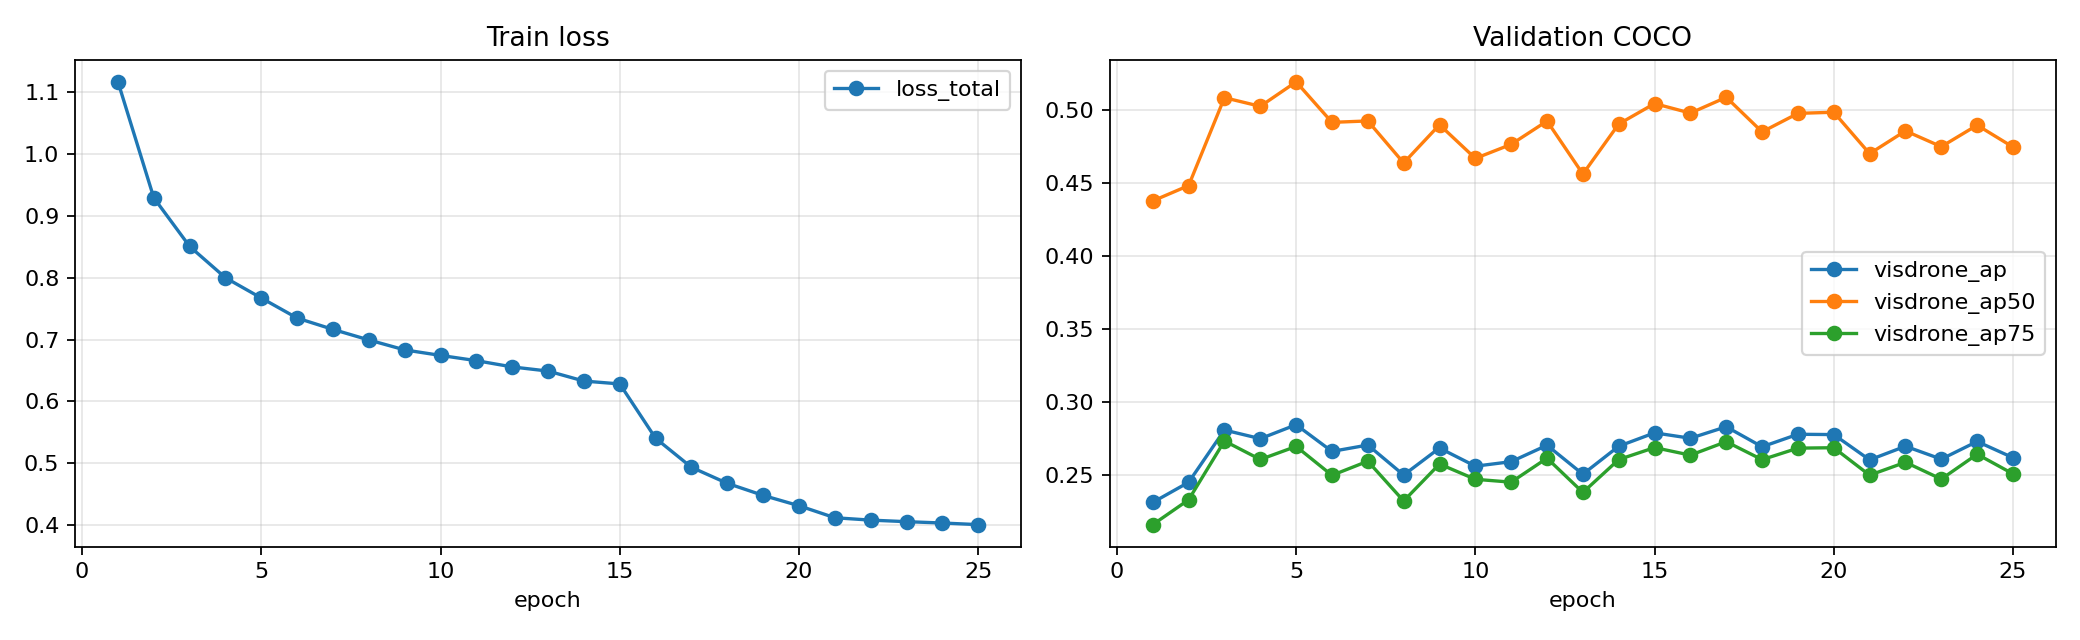

Artifacts để Save Version / tải về: /kaggle/working/faster_rcnn_runs/f5


In [6]:
import json
import pandas as pd
from IPython.display import Image as DisplayImage, display

RUN_DIR = OUTPUT_ROOT / EXPERIMENT.lower()
summary = json.loads((RUN_DIR / "summary.json").read_text())
display(pd.DataFrame([summary]))
display(pd.read_csv(RUN_DIR / "history.csv"))
if (RUN_DIR / "learning_curves.png").is_file():
    display(DisplayImage(filename=str(RUN_DIR / "learning_curves.png")))
print("Artifacts để Save Version / tải về:", RUN_DIR)
